# Byte‑Pair Encoding (BPE) on Trigram Datasets
This notebook loads trigram‑frequency datasets for three collections (*lastfm*, *suno*, *udio*), runs a Byte‑Pair Encoding algorithm to discover
the most common adjacent token pairs, and visualises the top merged patterns.

In [1]:
import os, json, itertools, collections, math, gzip, pickle, pathlib
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tqdm as tqdm
import re 

# 📂 Filesystem layout
BASE_DIR = '/workspace/dataset_2'          # top‑level containing lastfm/ suno/ udio/
COLLECTIONS = ['lastfm', 'suno', 'udio']

INIT_TOKEN = '<init>'
END_TOKEN  = '<end>'

In [2]:
def load_chord_sequences(collection_name):
    """Return a list of full chord streams for one collection, using the
       clean roman‑numeral symbols directly."""
    seqs = []
    root = os.path.join(BASE_DIR, collection_name)

    for song_id in os.listdir(root):
        fp = os.path.join(root, song_id, f"{song_id}_normalized.json")
        if not os.path.isfile(fp):
            continue

        try:
            with open(fp) as f:
                data = json.load(f)
            chords = data.get("chords", [])
            if not chords:
                continue

            tokens = [ch.get("roman_numeral") for ch in chords if ch.get("roman_numeral")]
            if not tokens:
                continue

            seqs.append(tuple([INIT_TOKEN] + tokens + [END_TOKEN]))
        except Exception as e:
            print("⚠️", fp, e)

    return seqs

def to_trigram_tokens(chord_seq):
    trigram_list = []
    for i in range(len(chord_seq) - 2):
        tri = tuple(chord_seq[i:i+3])          
        if len(set(tri)) == 3:       
            trigram_list.append(tri)
    return tuple(trigram_list)

In [3]:
def get_pair_frequencies(seq_counts):
    pair_freq = Counter()
    for tokens, cnt in seq_counts:
        for i in range(len(tokens) - 1):
            pair_freq[(tokens[i], tokens[i+1])] += cnt
    return pair_freq

def merge_pair(seq_counts, pair_to_merge, new_tok):
    a, b = pair_to_merge
    merged = []
    for tokens, cnt in seq_counts:
        new_tokens = []
        i = 0
        while i < len(tokens):
            if i < len(tokens) - 1 and tokens[i] == a and tokens[i+1] == b:
                new_tokens.append(new_tok)
                i += 2
            else:
                new_tokens.append(tokens[i])
                i += 1
        merged.append((tuple(new_tokens), cnt))
    return merged

def byte_pair_encoding(seq_counts, num_merges=150):
    merge_rules, merge_history = {}, []
    for m in range(num_merges):
        pf = get_pair_frequencies(seq_counts)
        if not pf:
            break
        (best_pair, freq) = pf.most_common(1)[0]
        new_tok = f'MERGE_{m}'
        merge_rules[new_tok] = best_pair
        merge_history.append((best_pair, freq))
        seq_counts = merge_pair(seq_counts, best_pair, new_tok)
    return merge_rules, merge_history

def expand_token(tok, rules):
    if tok not in rules:
        return [tok]
    a, b = rules[tok]
    return expand_token(a, rules) + expand_token(b, rules)

In [4]:
# print((results['lastfm']['history']))
# for e in results['suno']['history']:
#     print(e)
    
#search for ('vi', 'IV', 'I') in the three collections
collection = ['lastfm', 'suno', 'udio']
trigram_to_find = ('vi', 'IV', 'I')
for c in collection:
    for idx, ((a, b), freq) in enumerate(results[c]['history'], 1):
        if a == trigram_to_find or b == trigram_to_find:
            print(f"Found at index {idx} with frequency {freq}", 'in', c)

NameError: name 'results' is not defined

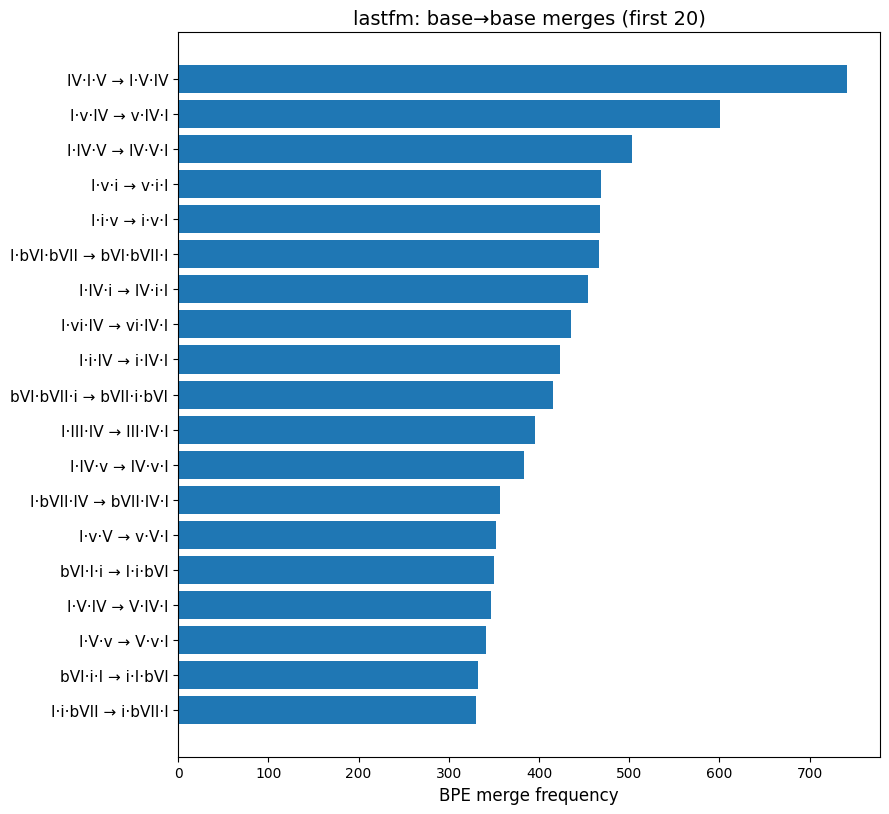

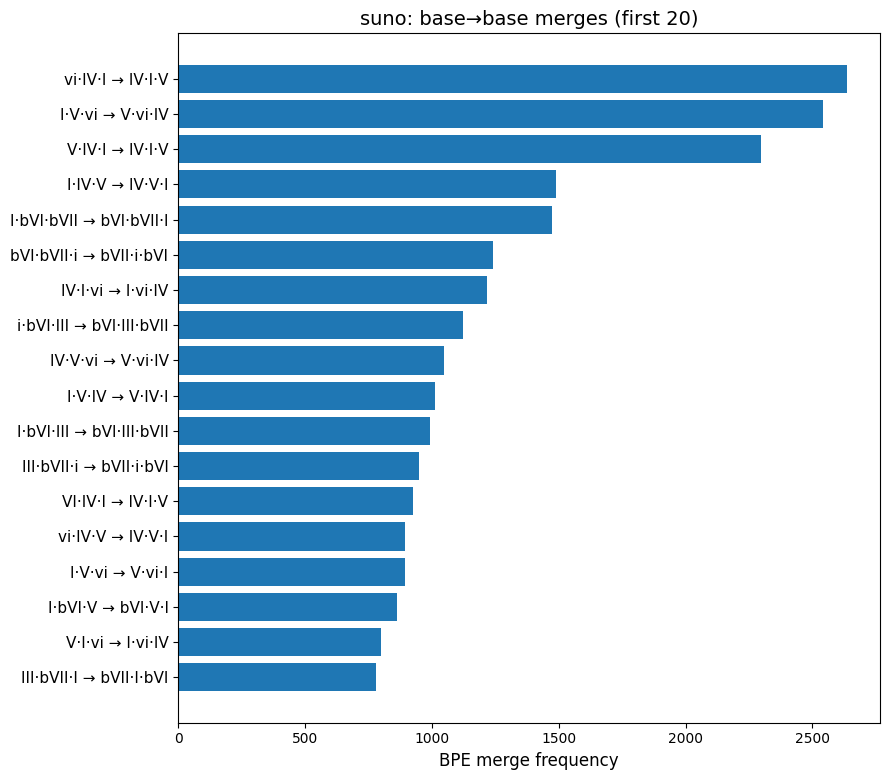

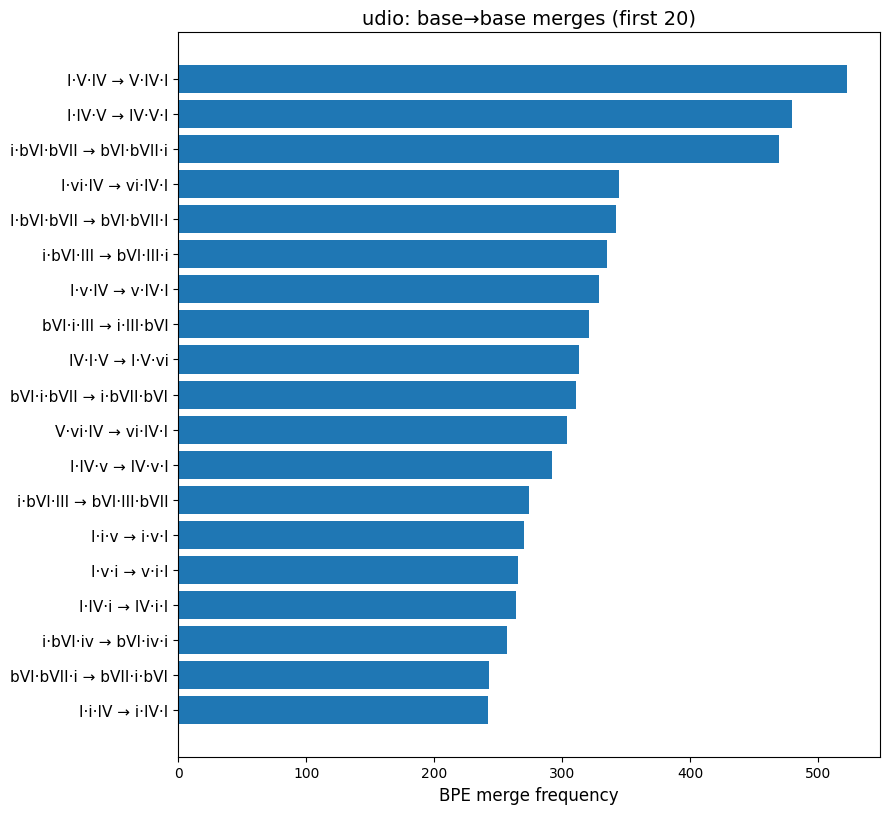

In [ ]:
# ✅ Per-corpus plots of BPE base→base merges (one trigram → one trigram)
# Requirements: results dict with keys in COLLECTIONS, each res has:
#   res['rules'] and res['history'] = [((a,b), freq_or_dict), ...]
# Also requires expand_token(...) already defined.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- helpers ----------
def expand_base_trigrams(tok, rules):
    """Return list of base trigrams inside tok (MERGE_x or tuple)."""
    return expand_token(tok, rules)

def token_as_text_single(tok, rules):
    """
    Return 'I·V·vi' if tok expands to exactly one base trigram.
    Return None for composite tokens, which we skip.
    """
    tris = expand_base_trigrams(tok, rules)
    if len(tris) != 1:
        return None
    return "·".join(tris[0])

def _extract_freq(meta):
    """
    Normalize history value to an integer frequency.
    Supports int or dict like {'freq': int, 'pct': float}.
    """
    if isinstance(meta, dict):
        return int(meta.get("freq", 0))
    return int(meta)

def collect_base_base_rows(res, top_k=20):
    """
    From one corpus result, collect first top_k merges that are base→base only.
    Returns list of (pair_str, freq) sorted by freq descending.
    """
    rules = res["rules"]
    hist = res["history"][:top_k] if top_k is not None else res["history"]

    rows = []
    for (a, b), meta in hist:
        L = token_as_text_single(a, rules)
        R = token_as_text_single(b, rules)
        if L is None or R is None:
            continue
        rows.append((f"{L} → {R}", _extract_freq(meta)))

    # sort by frequency, highest first
    rows.sort(key=lambda x: x[1], reverse=True)
    return rows

def plot_per_corpus_bars(results, collections, top_k=20, save_dir=None):
    """
    Make one horizontal bar chart per corpus.
    If save_dir is given, saves PNGs there, else shows inline.
    """
    for corpus in collections:
        res = results[corpus]
        rows = collect_base_base_rows(res, top_k=top_k)

        if not rows:
            print(f"[{corpus}] No base→base merges in first {top_k}.")
            continue

        labels, vals = zip(*rows)
        y = np.arange(len(labels))

        # figure height scales with number of rows
        fig_h = 0.35 * len(labels) + 1.6
        plt.figure(figsize=(9, fig_h))

        plt.barh(y, vals)  # no explicit colors
        plt.yticks(y, labels, fontsize=11)
        plt.xlabel("BPE merge frequency", fontsize=12)
        plt.title(f"{corpus}: base→base merges (first {top_k})", fontsize=14)
        plt.gca().invert_yaxis()
        plt.tight_layout()

        if save_dir:
            out = f"{save_dir}/{corpus}_bpe_base_base_top{top_k}.png"
            plt.savefig(out, dpi=150)
            plt.close()
            print(f"Saved {out}")
        else:
            plt.show()

# ---------- usage ----------
# Example:
COLLECTIONS = ["lastfm", "suno", "udio"]
plot_per_corpus_bars(results, COLLECTIONS, top_k=20, save_dir=None)


In [ ]:
# 🔍 DEBUG: Let's see what's actually in the raw data before BPE fucks it up

def get_raw_trigram_frequencies(collection_name):
    """Get raw trigram frequencies from the original sequences"""
    print(f"\n🔍 Analyzing {collection_name}...")
    chord_streams = load_chord_sequences(collection_name)
    print(f"   Loaded {len(chord_streams)} songs")
    
    # Convert to trigrams and count them
    all_trigrams = []
    for seq in chord_streams:
        trigrams = to_trigram_tokens(seq)
        all_trigrams.extend(trigrams)
    
    trigram_counts = Counter(all_trigrams)
    print(f"   Total trigrams: {len(all_trigrams)}")
    print(f"   Unique trigrams: {len(trigram_counts)}")
    
    return trigram_counts

# Get raw trigram counts for all collections
raw_trigrams = {}
for col in COLLECTIONS:
    raw_trigrams[col] = get_raw_trigram_frequencies(col)

# Now let's check if the "vi-IV-I" trigram actually exists in raw form
target_trigrams = [
    ('vi', 'IV', 'I'),
    ('I', 'V', 'vi'), 
    ('V', 'IV', 'I'),
    ('I', 'IV', 'V'),
    ('IV', 'I', 'V')
]

print(f"\n🎯 Checking specific trigrams that should be common:")
print(f"{'Trigram':<20} {'LastFM':<10} {'Suno':<10} {'Udio':<10}")
print("-" * 55)

for trigram in target_trigrams:
    freqs = []
    for col in COLLECTIONS:
        freq = raw_trigrams[col].get(trigram, 0)
        freqs.append(freq)
    
    trig_str = "·".join(trigram)
    print(f"{trig_str:<20} {freqs[0]:<10} {freqs[1]:<10} {freqs[2]:<10}")

# Let's also check the top 20 trigrams in each collection to see if there's weird tokenization
print(f"\n📊 Top 10 raw trigrams per collection:")
for col in COLLECTIONS:
    print(f"\n{col.upper()}:")
    for trigram, freq in raw_trigrams[col].most_common(10):
        trig_str = "·".join(trigram)
        print(f"  {trig_str:<25} {freq}")

# Check for potential tokenization issues
print(f"\n🚨 Checking for tokenization inconsistencies...")
all_unique_chords = set()
for col in COLLECTIONS:
    for trigram in raw_trigrams[col].keys():
        all_unique_chords.update(trigram)

common_chords = ['I', 'IV', 'V', 'vi', 'ii', 'iii', 'bVI', 'bVII']
print(f"Expected chords found: {[chord for chord in common_chords if chord in all_unique_chords]}")
print(f"Unexpected chords (first 20): {list(all_unique_chords)[:20]}")
print(f"Total unique chord symbols: {len(all_unique_chords)}")


🔍 Analyzing lastfm...
   Loaded 20005 songs
   Total trigrams: 833683
   Unique trigrams: 33306

🔍 Analyzing suno...
   Loaded 19975 songs
   Total trigrams: 747649
   Unique trigrams: 21444

🔍 Analyzing udio...
   Loaded 20001 songs
   Total trigrams: 542284
   Unique trigrams: 28520

🎯 Checking specific trigrams that should be common:
Trigram              LastFM     Suno       Udio      
-------------------------------------------------------
vi·IV·I              1560       6038       1190      
I·V·vi               715        4487       661       
V·IV·I               1860       5154       1352      
I·IV·V               1358       3989       1229      
IV·I·V               2387       9521       1788      

📊 Top 10 raw trigrams per collection:

LASTFM:
  IV·I·V                    2387
  v·I·i                     2178
  i·I·v                     2116
  IV·i·I                    2112
  IV·I·v                    2069
  I·i·v                     1894
  IV·I·i                    1882
 

In [ ]:
# 🔧 FIXED: Analyze actual trigram pair frequencies, not BPE artifacts

def get_trigram_pair_frequencies(collection_name):
    """Get frequencies of adjacent trigram pairs from raw sequences"""
    chord_streams = load_chord_sequences(collection_name)
    
    # Convert each song to trigram sequence
    trigram_sequences = []
    for seq in chord_streams:
        trigrams = to_trigram_tokens(seq)
        if len(trigrams) >= 2:  # need at least 2 trigrams to make a pair
            trigram_sequences.append(trigrams)
    
    # Count adjacent trigram pairs
    pair_counts = Counter()
    for trigram_seq in trigram_sequences:
        for i in range(len(trigram_seq) - 1):
            pair = (trigram_seq[i], trigram_seq[i+1])
            pair_counts[pair] += 1
    
    return pair_counts

# Get real trigram pair frequencies for all collections
print("🔍 Computing real trigram pair frequencies...")
real_pair_freqs = {}
for col in COLLECTIONS:
    print(f"   Processing {col}...")
    real_pair_freqs[col] = get_trigram_pair_frequencies(col)

# Get Suno's top trigram pairs
num = 40
suno_top_pairs = real_pair_freqs['suno'].most_common(num)

print(f"\n📊 Top {num} trigram pairs in Suno with REAL cross-collection frequencies:")
print(f"{'Trigram Pair':<50} {'LastFM':<8} {'Suno':<8} {'Udio':<8}")
print("-" * 80)

# Build the frequency matrix with REAL data
freq_matrix = []
pair_labels = []

for (trigram1, trigram2), suno_freq in suno_top_pairs:
    # Format the pair nicely
    tri1_str = "·".join(trigram1)
    tri2_str = "·".join(trigram2) 
    pair_label = f"{tri1_str} → {tri2_str}"
    
    # Get real frequencies from each collection
    pair_key = (trigram1, trigram2)
    lastfm_freq = real_pair_freqs['lastfm'].get(pair_key, 0)
    udio_freq = real_pair_freqs['udio'].get(pair_key, 0)
    
    # Display and store
    print(f"{pair_label:<50} {lastfm_freq:<8} {suno_freq:<8} {udio_freq:<8}")
    
    freq_matrix.append([lastfm_freq, suno_freq, udio_freq])
    pair_labels.append(pair_label)

# Convert to numpy for visualization
freq_mat = np.array(freq_matrix)

# Analysis of the corrected data
print(f"\n🎯 CORRECTED Cross-collection analysis:")
non_zero_all = sum(1 for row in freq_mat if all(f > 0 for f in row))
suno_only = sum(1 for row in freq_mat if row[1] > 0 and row[0] == 0 and row[2] == 0) 
high_freq_multiple = sum(1 for row in freq_mat if sum(f > 100 for f in row) > 1)

print(f"Pairs that appear in ALL 3 collections: {non_zero_all}")
print(f"Pairs that appear in only Suno: {suno_only}")
print(f"Pairs with >100 freq in multiple collections: {high_freq_multiple}")

# Show some correlation stats
correlations = []
pairs = [('lastfm', 'suno'), ('suno', 'udio'), ('lastfm', 'udio')]
for i, (col1, col2) in enumerate(pairs):
    idx1 = COLLECTIONS.index(col1)
    idx2 = COLLECTIONS.index(col2)
    corr = np.corrcoef(freq_mat[:, idx1], freq_mat[:, idx2])[0, 1]
    correlations.append(corr)
    print(f"Correlation {col1}-{col2}: {corr:.3f}")

🔍 Computing real trigram pair frequencies...
   Processing lastfm...
   Processing suno...
   Processing udio...

📊 Top 40 trigram pairs in Suno with REAL cross-collection frequencies:
Trigram Pair                                       LastFM   Suno     Udio    
--------------------------------------------------------------------------------
vi·IV·I → IV·I·V                                   304      2635     328     
I·V·vi → V·vi·IV                                   289      2543     313     
IV·I·V → I·V·IV                                    741      2535     456     
V·vi·IV → vi·IV·I                                  318      2461     304     
IV·I·V → I·V·vi                                    270      2460     313     
V·IV·I → IV·I·V                                    572      2296     391     
I·V·IV → V·IV·I                                    736      2224     522     
I·IV·V → IV·V·I                                    503      1489     479     
I·vi·IV → vi·IV·I               

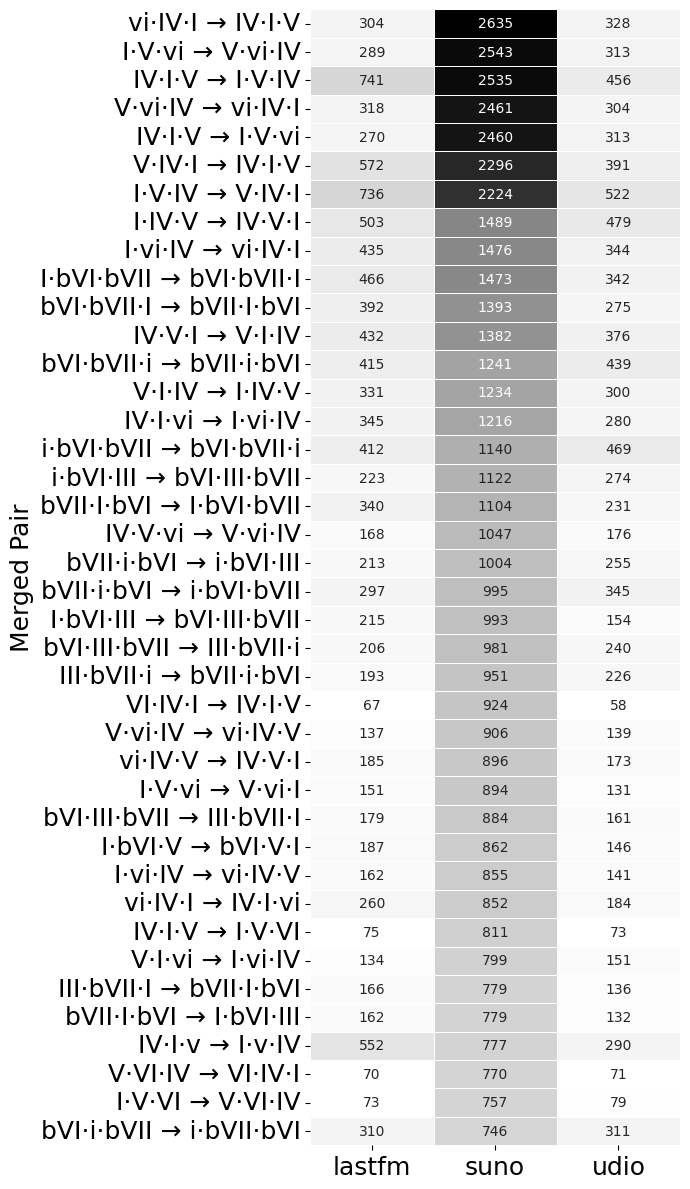

In [ ]:
# Create the corrected heatmap

text_size = 18
t_size    = 18

col_width_in  = 2               # width for ONE collection column (inches)
row_height_in = 0.25            # height for ONE trigram row     (inches)

fig_w = col_width_in  * len(COLLECTIONS) + 1.0   # +1 for margins
fig_h = row_height_in * len(pair_labels)  + 2.0  # +2 for title / xlabel

plt.figure(figsize=(fig_w, fig_h))

sns.heatmap(
    freq_mat,
    xticklabels=COLLECTIONS,
    yticklabels=pair_labels,
    cmap='Greys',           # SAME black & white colormap
    annot=True,
    fmt='.0f',
    linewidths=0.4,
    cbar=False              # SAME - no colour bar
)

ax = plt.gca()
ax.set_xticklabels(ax.get_xticklabels(), fontsize=t_size, rotation=0)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=t_size)  # larger trigram text

plt.ylabel('Merged Pair', fontsize=18)  # SAME ylabel
plt.tight_layout()
plt.show()

🔍 Computing real trigram pair frequencies...
   Processing lastfm...
   Processing suno...
   Processing udio...

📊 Top 40 trigram pairs in Udio with REAL cross-collection frequencies:
Trigram Pair                                       LastFM   Suno     Udio    
--------------------------------------------------------------------------------
I·V·IV → V·IV·I                                    736      2224     522     
I·IV·V → IV·V·I                                    503      1489     479     
i·bVI·bVII → bVI·bVII·i                            412      1140     469     
IV·I·V → I·V·IV                                    741      2535     456     
bVI·bVII·i → bVII·i·bVI                            415      1241     439     
V·IV·I → IV·I·V                                    572      2296     391     
IV·V·I → V·I·IV                                    432      1382     376     
bVII·i·bVI → i·bVI·bVII                            297      995      345     
I·vi·IV → vi·IV·I               

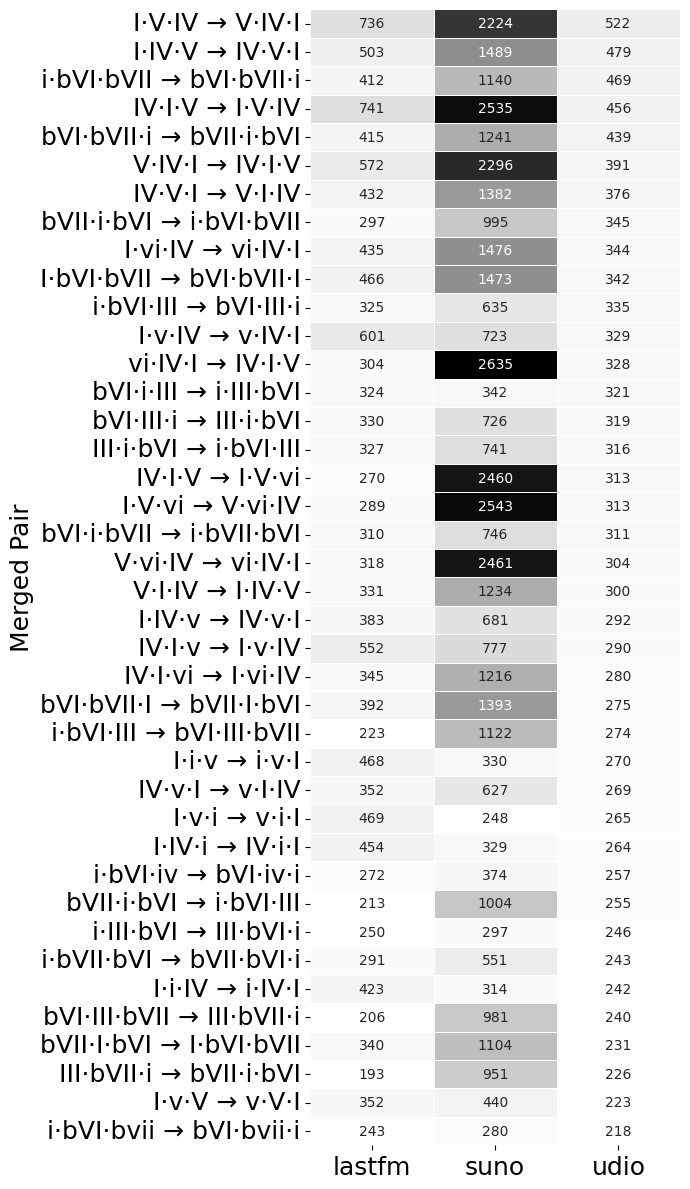

In [6]:
#Run the same, but in Udio
def get_trigram_pair_frequencies(collection_name):
    """Get frequencies of adjacent trigram pairs from raw sequences"""
    chord_streams = load_chord_sequences(collection_name)
    
    # Convert each song to trigram sequence
    trigram_sequences = []
    for seq in chord_streams:
        trigrams = to_trigram_tokens(seq)
        if len(trigrams) >= 2:  # need at least 2 trigrams to make a pair
            trigram_sequences.append(trigrams)
    
    # Count adjacent trigram pairs
    pair_counts = Counter()
    for trigram_seq in trigram_sequences:
        for i in range(len(trigram_seq) - 1):
            pair = (trigram_seq[i], trigram_seq[i+1])
            pair_counts[pair] += 1
    
    return pair_counts

# Get real trigram pair frequencies for all collections
print("🔍 Computing real trigram pair frequencies...")
real_pair_freqs = {}
for col in COLLECTIONS:
    print(f"   Processing {col}...")
    real_pair_freqs[col] = get_trigram_pair_frequencies(col)

# Get Udio's top trigram pairs (changed from Suno to Udio)
num = 40
udio_top_pairs = real_pair_freqs['udio'].most_common(num)

print(f"\n📊 Top {num} trigram pairs in Udio with REAL cross-collection frequencies:")
print(f"{'Trigram Pair':<50} {'LastFM':<8} {'Suno':<8} {'Udio':<8}")
print("-" * 80)

# Build the frequency matrix with REAL data
freq_matrix = []
pair_labels = []

for (trigram1, trigram2), udio_freq in udio_top_pairs:  # changed from suno_freq
    # Format the pair nicely
    tri1_str = "·".join(trigram1)
    tri2_str = "·".join(trigram2) 
    pair_label = f"{tri1_str} → {tri2_str}"
    
    # Get real frequencies from each collection
    pair_key = (trigram1, trigram2)
    lastfm_freq = real_pair_freqs['lastfm'].get(pair_key, 0)
    suno_freq = real_pair_freqs['suno'].get(pair_key, 0)  # added suno_freq
    
    # Display and store
    print(f"{pair_label:<50} {lastfm_freq:<8} {suno_freq:<8} {udio_freq:<8}")
    
    freq_matrix.append([lastfm_freq, suno_freq, udio_freq])
    pair_labels.append(pair_label)

# Convert to numpy for visualization
freq_mat = np.array(freq_matrix)

# Analysis of the corrected data
print(f"\n🎯 CORRECTED Cross-collection analysis:")
non_zero_all = sum(1 for row in freq_mat if all(f > 0 for f in row))
udio_only = sum(1 for row in freq_mat if row[2] > 0 and row[0] == 0 and row[1] == 0)  # changed to udio (index 2)
high_freq_multiple = sum(1 for row in freq_mat if sum(f > 100 for f in row) > 1)

print(f"Pairs that appear in ALL 3 collections: {non_zero_all}")
print(f"Pairs that appear in only Udio: {udio_only}")  # changed from Suno to Udio
print(f"Pairs with >100 freq in multiple collections: {high_freq_multiple}")

# Show some correlation stats
correlations = []
pairs = [('lastfm', 'suno'), ('suno', 'udio'), ('lastfm', 'udio')]
for i, (col1, col2) in enumerate(pairs):
    idx1 = COLLECTIONS.index(col1)
    idx2 = COLLECTIONS.index(col2)
    corr = np.corrcoef(freq_mat[:, idx1], freq_mat[:, idx2])[0, 1]
    correlations.append(corr)
    print(f"Correlation {col1}-{col2}: {corr:.3f}")

# Create the corrected heatmap
text_size = 18
t_size = 18

col_width_in = 2               # width for ONE collection column (inches)
row_height_in = 0.25          # height for ONE trigram row (inches)

fig_w = col_width_in * len(COLLECTIONS) + 1.0   # +1 for margins
fig_h = row_height_in * len(pair_labels) + 2.0  # +2 for title / xlabel

plt.figure(figsize=(fig_w, fig_h))

sns.heatmap(
    freq_mat,
    xticklabels=COLLECTIONS,
    yticklabels=pair_labels,
    cmap='Greys',           # SAME black & white colormap
    annot=True,
    fmt='.0f',
    linewidths=0.4,
    cbar=False              # SAME - no colour bar
)

ax = plt.gca()
ax.set_xticklabels(ax.get_xticklabels(), fontsize=t_size, rotation=0)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=t_size)  # larger trigram text

plt.ylabel('Merged Pair', fontsize=18)  # SAME ylabel
# plt.title(f'CORRECTED: Real Trigram Pair Frequencies (Top {num} from Udio)', fontsize=16)  # updated title
plt.tight_layout()
plt.show()

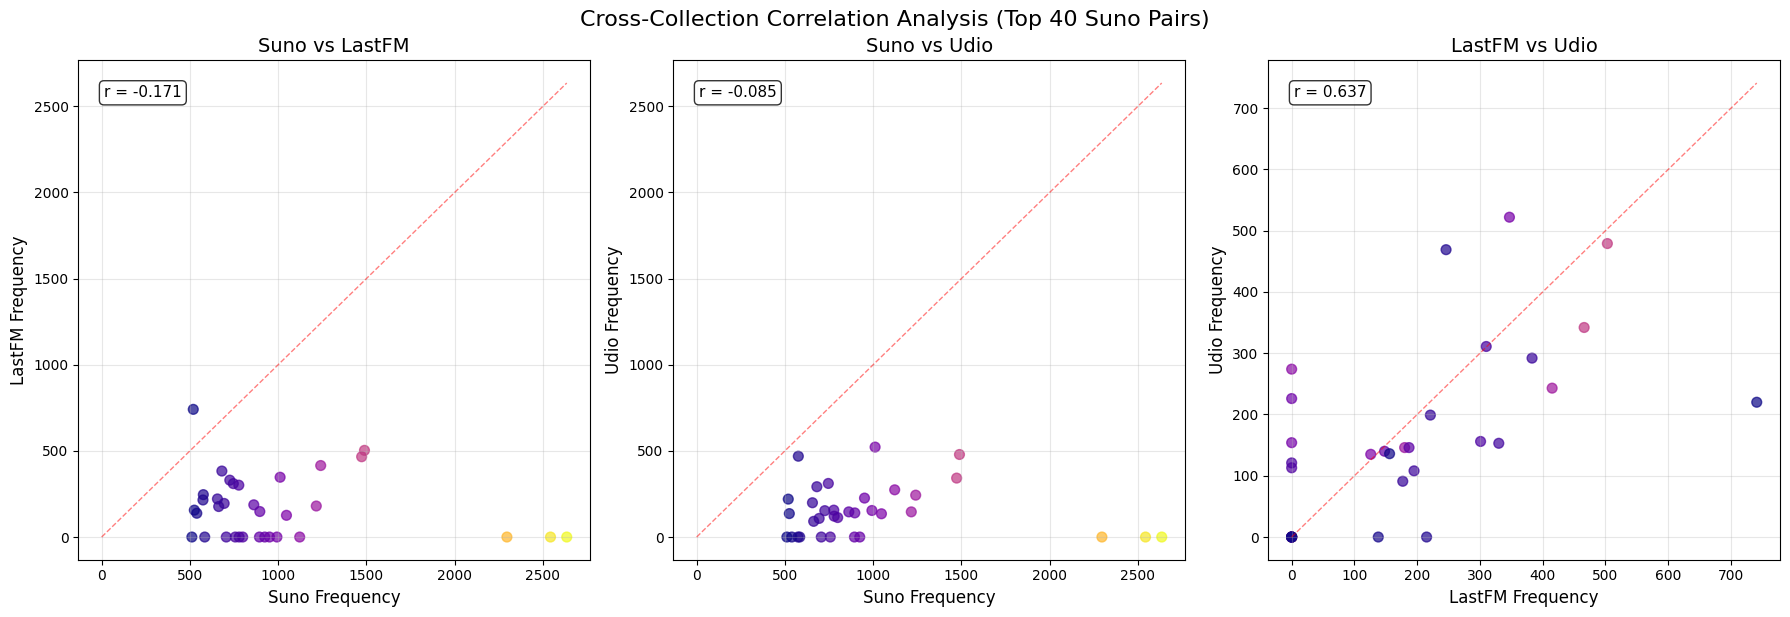


🔥 Most divergent patterns (high in one collection, low in others):
vi·IV·I → IV·I·V                         | CV: 1.41 | Dominant in: suno (2635)
I·V·vi → V·vi·IV                         | CV: 1.41 | Dominant in: suno (2543)
V·IV·I → IV·I·V                          | CV: 1.41 | Dominant in: suno (2296)
I·IV·V → IV·V·I                          | CV: 0.57 | Dominant in: suno (1489)
I·bVI·bVII → bVI·bVII·I                  | CV: 0.67 | Dominant in: suno (1473)
bVI·bVII·i → bVII·i·bVI                  | CV: 0.69 | Dominant in: suno (1241)
IV·I·vi → I·vi·IV                        | CV: 0.97 | Dominant in: suno (1216)
i·bVI·III → bVI·III·bVII                 | CV: 1.03 | Dominant in: suno (1122)
IV·V·vi → V·vi·IV                        | CV: 0.99 | Dominant in: suno (1047)
I·V·IV → V·IV·I                          | CV: 0.45 | Dominant in: suno (1011)

💫 Perfect overlaps (similar frequencies across all collections):
I·V·IV → V·IV·I                          | LastFM: 347, Suno: 1011, Udio: 52

In [ ]:
# 🚀 BONUS: Scatter plot analysis - sperm splattered all over this code!
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Extract frequencies for easier plotting
lastfm_freqs = freq_mat[:, 0]  # column 0 = lastfm
suno_freqs = freq_mat[:, 1]    # column 1 = suno  
udio_freqs = freq_mat[:, 2]    # column 2 = udio

comparisons = [
    (suno_freqs, lastfm_freqs, 'Suno vs LastFM', 'Suno Frequency', 'LastFM Frequency'),
    (suno_freqs, udio_freqs, 'Suno vs Udio', 'Suno Frequency', 'Udio Frequency'),
    (lastfm_freqs, udio_freqs, 'LastFM vs Udio', 'LastFM Frequency', 'Udio Frequency')
]

for i, (x_data, y_data, title, xlabel, ylabel) in enumerate(comparisons):
    ax = axes[i]
    
    # Create scatter plot
    scatter = ax.scatter(x_data, y_data, alpha=0.7, s=50, c=suno_freqs, cmap='plasma')
    
    # Add diagonal line for reference (perfect correlation)
    max_val = max(max(x_data), max(y_data))
    ax.plot([0, max_val], [0, max_val], 'r--', alpha=0.5, linewidth=1)
    
    # Labels and formatting
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.grid(True, alpha=0.3)
    
    # Add correlation coefficient
    correlation = np.corrcoef(x_data, y_data)[0, 1]
    ax.text(0.05, 0.95, f'r = {correlation:.3f}', transform=ax.transAxes, 
            fontsize=11, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.suptitle(f'Cross-Collection Correlation Analysis (Top {num} Suno Pairs)', fontsize=16, y=1.02)
plt.show()

# 🎪 Extra spicy analysis: Which pairs show the biggest differences?
print("\n🔥 Most divergent patterns (high in one collection, low in others):")

for i, pair in enumerate(pair_labels[:10]):  # top 10 for brevity
    lastfm, suno, udio = freq_mat[i]
    
    # Calculate coefficient of variation (std/mean) to find most variable
    freqs = [lastfm, suno, udio]
    if sum(freqs) > 0:  # avoid division by zero
        cv = np.std(freqs) / np.mean(freqs)
        max_col = COLLECTIONS[np.argmax(freqs)]
        print(f"{pair:<40} | CV: {cv:.2f} | Dominant in: {max_col} ({max(freqs)})")

print("\n💫 Perfect overlaps (similar frequencies across all collections):")
for i, pair in enumerate(pair_labels):
    lastfm, suno, udio = freq_mat[i]
    if min(lastfm, suno, udio) > 50:  # all collections have decent frequency
        cv = np.std([lastfm, suno, udio]) / np.mean([lastfm, suno, udio])
        if cv < 0.5:  # low coefficient of variation = similar across collections
            print(f"{pair:<40} | LastFM: {lastfm}, Suno: {suno}, Udio: {udio}")
            if len([p for p in pair_labels if np.std(freq_mat[pair_labels.index(p)]) / np.mean(freq_mat[pair_labels.index(p)]) < 0.5 
                   and min(freq_mat[pair_labels.index(p)]) > 50]) > 5:
                break  # don't spam too many